## Train a machine learning model and track with MLflow

In [9]:

# Azure Open Dataset connection details
blob_account_name = "azureopendatastorage"
blob_container_name = "mlsamples"
blob_relative_path = "diabetes"
blob_sas_token = r""  # Blank  since container is Anonymous access

# Set Spark config to access blob storage
wasbs_path = f"wasbs://%s@%s.blob.core.windows.net/%s" % (blob_container_name, blob_account_name, blob_relative_path)
# spark.conf.set("fs.azure.sas.%s.%s.blob.core.windows.net" % (blob_container_name, blob_account_name), blob_sas_token)
spark.conf.set(f"fs.azure.sas.{blob_container_name}.{blob_account_name}.blob.core.windows.net", blob_sas_token)
print("Remote blob path :" + wasbs_path)

# Spark read parquet , note that it won't load any data yet by now
df = spark.read.parquet(wasbs_path)


StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 36, Finished, Available, Finished, False)

Remote blob path :wasbs://mlsamples@azureopendatastorage.blob.core.windows.net/diabetes


In [10]:
display (df)

StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 37, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 526a1de3-2ef4-40d9-99e1-7d6607c070b1)

In [11]:
import pandas as pd

df = df.toPandas()
df.head()
     

StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 39, Finished, Available, Finished, False)

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


## Train Machine Learning Model

In [12]:
from sklearn.model_selection import train_test_split

X,y = df[['AGE','SEX','BMI','BP','S1','S2','S3','S4','S5','S6']].values, df['Y'].values

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, random_state=0)

StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 41, Finished, Available, Finished, False)

In [13]:

import mlflow

experiment_name = "experiment-diabetes"
mlflow.set_experiment(experiment_name)

StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 42, Finished, Available, Finished, False)

2026/04/15 03:30:37 INFO mlflow.tracking.fluent: Experiment with name 'experiment-diabetes' does not exist. Creating a new experiment.


<Experiment: artifact_location='sds://onelakeaustraliaeast.pbidedicated.windows.net/ce6a769f-2db4-4f9b-b01a-04bf45137967/6a7553da-f96a-4ee9-b183-c5d25ce1c45a', creation_time=1776223838769, experiment_id='6a7553da-f96a-4ee9-b183-c5d25ce1c45a', last_update_time=1776223838769, lifecycle_stage='active', name='experiment-diabetes', tags={}>

In [14]:
from sklearn.linear_model import LinearRegression

with mlflow.start_run():
    mlflow.autolog()

    model = LinearRegression()
    model.fit(X_train, y_train)

    mlflow.log_param("estimator","LinearRegression")

StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 43, Finished, Available, Finished, False)

2026/04/15 03:32:12 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/04/15 03:32:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils."


In [15]:
from sklearn.tree import DecisionTreeRegressor

with mlflow.start_run():
    mlflow.autolog()

    model = DecisionTreeRegressor(max_depth=5)
    model.fit(X_train, y_train)\

    mlflow.log_param("estimator", "DecisionTreeRegressor")


StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 44, Finished, Available, Finished, False)

2026/04/15 03:34:15 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


## Use MLFlow to search and view experiments

In [16]:
import mlflow
experiments = mlflow.search_experiments()
for exp in experiments:
    print(exp.name)


StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 45, Finished, Available, Finished, False)

experiment-diabetes
diabetes-classification
diabetes-regression


In [17]:
experiment_name = "experiment-diabetes"
exp = mlflow.get_experiment_by_name(experiment_name)
print(exp)

StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 46, Finished, Available, Finished, False)

<Experiment: artifact_location='sds://onelakeaustraliaeast.pbidedicated.windows.net/ce6a769f-2db4-4f9b-b01a-04bf45137967/6a7553da-f96a-4ee9-b183-c5d25ce1c45a', creation_time=1776223838769, experiment_id='6a7553da-f96a-4ee9-b183-c5d25ce1c45a', last_update_time=1776223838769, lifecycle_stage='active', name='experiment-diabetes', tags={}>


In [18]:
mlflow.search_runs(exp.experiment_id)

StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 47, Finished, Available, Finished, False)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.training_score,metrics.training_mean_absolute_error,metrics.training_r2_score,metrics.training_mean_squared_error,...,tags.estimator_class,tags.synapseml.run.artifactJobId,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.estimator_name,tags.synapseml.livy.id,tags.synapseml.user.name,tags.mlflow.source.type,tags.synapseml.user.id
0,f14fd5d6-af03-46f5-9a2e-68fb645800f5,6a7553da-f96a-4ee9-b183-c5d25ce1c45a,FINISHED,sds://onelakeaustraliaeast.pbidedicated.window...,2026-04-15 03:34:14.711000+00:00,2026-04-15 03:34:18.929000+00:00,0.732149,31.483440,0.732149,1683.830915,...,sklearn.tree._classes.DecisionTreeRegressor,f6d64012-1065-4244-971e-1a8bbf1d05e4,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,salmon_shirt_xjqg16lq,DecisionTreeRegressor,bb31195f-ffce-4b01-93a7-d315a8ea6edd,ML Data Engineer,LOCAL,2cf94cc7-36b6-4de6-a592-0b4881e06020
1,1f3d6b27-15e2-4b95-a60d-ca4a44536dbc,6a7553da-f96a-4ee9-b183-c5d25ce1c45a,FINISHED,sds://onelakeaustraliaeast.pbidedicated.window...,2026-04-15 03:32:11.852000+00:00,2026-04-15 03:32:31.910000+00:00,0.553938,43.054973,0.553938,2804.143561,...,sklearn.linear_model._base.LinearRegression,d0a1bfff-1d96-46e4-b22f-c6babc15b2a4,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,nice_station_b6v6607z,LinearRegression,bb31195f-ffce-4b01-93a7-d315a8ea6edd,ML Data Engineer,LOCAL,2cf94cc7-36b6-4de6-a592-0b4881e06020


In [19]:
mlflow.search_runs(exp.experiment_id, order_by=["start_time DESC"], max_results=2)

StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 48, Finished, Available, Finished, False)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.training_score,metrics.training_mean_absolute_error,metrics.training_r2_score,metrics.training_mean_squared_error,...,tags.estimator_class,tags.synapseml.run.artifactJobId,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.estimator_name,tags.synapseml.livy.id,tags.synapseml.user.name,tags.mlflow.source.type,tags.synapseml.user.id
0,f14fd5d6-af03-46f5-9a2e-68fb645800f5,6a7553da-f96a-4ee9-b183-c5d25ce1c45a,FINISHED,sds://onelakeaustraliaeast.pbidedicated.window...,2026-04-15 03:34:14.711000+00:00,2026-04-15 03:34:18.929000+00:00,0.732149,31.483440,0.732149,1683.830915,...,sklearn.tree._classes.DecisionTreeRegressor,f6d64012-1065-4244-971e-1a8bbf1d05e4,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,salmon_shirt_xjqg16lq,DecisionTreeRegressor,bb31195f-ffce-4b01-93a7-d315a8ea6edd,ML Data Engineer,LOCAL,2cf94cc7-36b6-4de6-a592-0b4881e06020
1,1f3d6b27-15e2-4b95-a60d-ca4a44536dbc,6a7553da-f96a-4ee9-b183-c5d25ce1c45a,FINISHED,sds://onelakeaustraliaeast.pbidedicated.window...,2026-04-15 03:32:11.852000+00:00,2026-04-15 03:32:31.910000+00:00,0.553938,43.054973,0.553938,2804.143561,...,sklearn.linear_model._base.LinearRegression,d0a1bfff-1d96-46e4-b22f-c6babc15b2a4,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,nice_station_b6v6607z,LinearRegression,bb31195f-ffce-4b01-93a7-d315a8ea6edd,ML Data Engineer,LOCAL,2cf94cc7-36b6-4de6-a592-0b4881e06020


In [22]:
df_results = mlflow.search_runs(
    exp.experiment_id, 
    order_by=["start_time DESC"], 
    max_results=2
)

# 2. Debug: Print columns to find the correct name for your estimator
print("Available columns:", df_results.columns.tolist())

df_plot = df_results[["params.estimator", "metrics.training_r2_score"]]

StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 53, Finished, Available, Finished, False)

Available columns: ['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time', 'end_time', 'metrics.training_score', 'metrics.training_mean_absolute_error', 'metrics.training_r2_score', 'metrics.training_mean_squared_error', 'metrics.training_root_mean_squared_error', 'params.splitter', 'params.random_state', 'params.min_impurity_decrease', 'params.max_depth', 'params.min_weight_fraction_leaf', 'params.min_samples_leaf', 'params.max_features', 'params.estimator', 'params.min_samples_split', 'params.ccp_alpha', 'params.criterion', 'params.max_leaf_nodes', 'params.copy_X', 'params.positive', 'params.n_jobs', 'params.fit_intercept', 'tags.synapseml.notebook.artifactId', 'tags.estimator_class', 'tags.synapseml.run.artifactJobId', 'tags.mlflow.source.name', 'tags.mlflow.user', 'tags.mlflow.runName', 'tags.estimator_name', 'tags.synapseml.livy.id', 'tags.synapseml.user.name', 'tags.mlflow.source.type', 'tags.synapseml.user.id']


StatementMeta(, bb31195f-ffce-4b01-93a7-d315a8ea6edd, 62, Finished, Available, Finished, False)

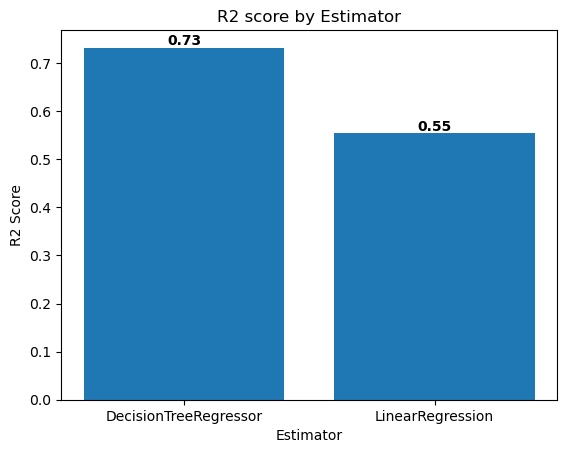

In [23]:
import matplotlib.pyplot as plt

# df_results = mlflow.search_runs(exp.experiment_id, order_by=["start_time DESC"], max_results=2)[["metrics.training_r2_score"]]

fig, ax = plt.subplots()
#ax.bar(df_results["params.estimator"], df_results["metrics.training_r2_score"])
ax.bar(df_plot["params.estimator"], df_plot["metrics.training_r2_score"])
ax.set_xlabel("Estimator")
ax.set_ylabel("R2 Score")
ax.set_title("R2 score by Estimator")

for i, v in enumerate(df_results["metrics.training_r2_score"]):
    ax.text(i, v, str(round(v,2)), ha='center', va='bottom', fontweight='bold')

plt.show()
